~o~ This Study: L-Band  ( GBT )  ~o~
SEFD : 10.04512371172085
Sens : 22.60454168760974
Max Distance (m) : 9.010168103403985e+23
EIRP : 2.3060640076240506e+24
EIRP (max drift rate) : 6.918192022872152e+25
BeamSize : 0.015329777696809932
Sky Coverage : 1.4869884365905635
CWTFM : 44.87204248957135
DFM : 9131833.149749747
~o~ This Study: S-Band  ( GBT )  ~o~
SEFD : 11.37462537944861
Sens : 25.596319263911028
EIRP : 2.6112783615742925e+24
EIRP (max drift rate) : 1.5667670169445756e+26
Max Distance (m) : 9.010168103403985e+23
BeamSize : 0.006520226808662067
Sky Coverage : 0.6324620004402205
CWTFM : 55.462657280777854
DFM : 4590880.763472115
~o~ This Study: C-Band  ( GBT )  ~o~
SEFD : 13.522281919624222
Sens : 30.429190733320805
Max Distance (m) : 9.010168103403985e+23
EIRP : 3.104316933340068e+24
EIRP (max drift rate) : 3.725180320008082e+26
BeamSize : 0.0009908646888199468
Sky Coverage : 0.09611387481553484
CWTFM : 48.19860501764843
DFM : 2175875.6852965537
~o~ This Study: 4-Band  ( GBT )  

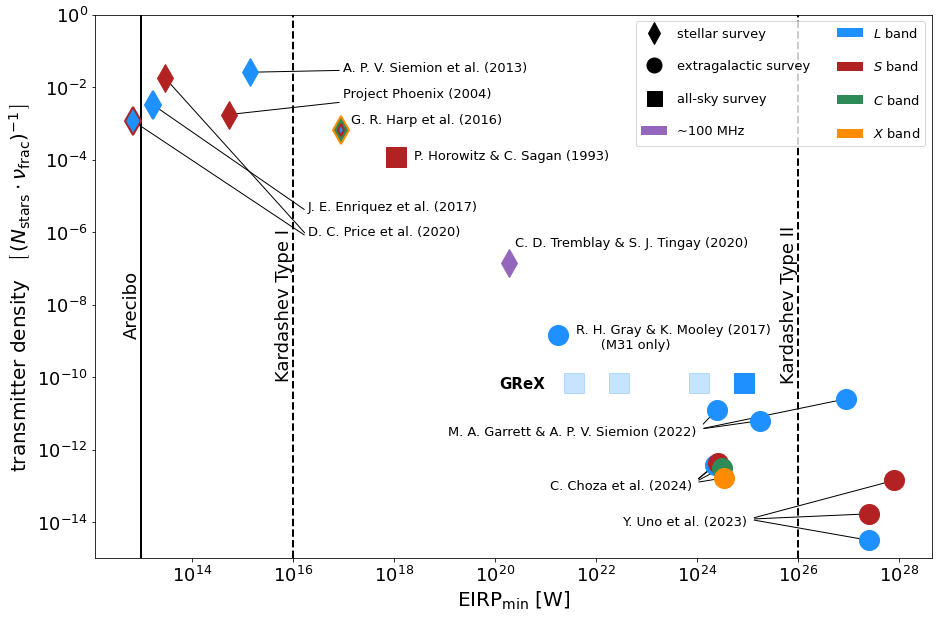

In [1]:
import os
import matplotlib.pyplot as plt

### check Carmen's X-band transmitter rate

wd = 'seti_limits_py3'
if os.getcwd().find(wd) == -1:
    os.chdir(wd)

from GReX_color_coded_ET_power_law import *

from LBand_SETI_compare import lband_compare
from SBand_SETI_compare import sband_compare 
from CBand_SETI_compare import cband_compare
from XBand_SETI_compare import xband_compare
from LBand_SETI_compare_nearby_stars import lband_compare as lband_j25
from SBand_SETI_compare_nearby_stars import sband_compare as sband_j25 
from CBand_SETI_compare_nearby_stars import cband_compare as cband_j25
from XBand_SETI_compare_nearby_stars import xband_compare as xband_j25
import numpy as np

def seti_compare(y_label_units=True):
    ''' Compare SETI project with previous surveys.
    ''' 

    ldist = 2.92e7
    sdist = 2.92e7
    cdist = 2.92e7
    xdist = 2.92e7

    dist_j25 = 50

    # Get dictionaries of plot-relevant values
    Lband = lband_compare(ldist, 33, save=False)
    Sband = sband_compare(sdist, 33, save=False)
    Cband = cband_compare(cdist, 33, save=False)
    Xband = xband_compare(xdist, 33, save=False)

    Lband_uncorr = lband_compare(ldist, 10, save=False)
    Sband_uncorr = sband_compare(sdist, 10, save=False)
    Cband_uncorr = cband_compare(cdist, 10, save=False)
    Xband_uncorr = xband_compare(xdist, 10, save=False)

    Lband_j25 = lband_j25(dist_j25, 33, save=False)
    Sband_j25 = sband_j25(dist_j25, 33, save=False)
    Cband_j25 = cband_j25(dist_j25, 33, save=False)
    Xband_j25 = xband_j25(dist_j25, 33, save=False)

    Lband_j25b = lband_j25(dist_j25, 10, save=False)
    Sband_j25b = sband_j25(dist_j25, 10, save=False)
    Cband_j25b = cband_j25(dist_j25, 10, save=False)
    Xband_j25b = xband_j25(dist_j25, 10, save=False)

    # Place all dictionaries in list --> Allows plotting via for-loop
    dict_list = [Lband, Sband, Cband, Xband]
    dict_list_uncorr = [Lband_uncorr, Sband_uncorr, Cband_uncorr, Xband_uncorr]
    colors = ['dodgerblue',  'firebrick', 'seagreen', 'darkorange']
    markers = [(6,2,0), (6,2,90), (6,2,180), (6,2,270)]

    #---------------------------------------------------------------------------------
    # plotting setup
    plt.ion()
    plt.figure(figsize=(15, 10))
    alpha = 0.7
    ms = 20
    fontsize = 20
    ticksize = fontsize - 2
    dot_size = ms - 12

    band_handles = {'L':[],'S':[],'C':[],'X':[]}
    band_letters = ['L','S','C','X']
    # Plot values for all 4 bands
    for i, (band_dict, band_dict_uncorr) in enumerate(zip(dict_list, dict_list_uncorr)): 
        print(i)
        print(band_dict)
        if i == 3:
            print(band_dict['EIRP'])
        
        
        leftbounds, = plt.plot(np.log10(band_dict['EIRP']),np.log10(1./band_dict['rarity']), marker='o', linestyle='None', color=colors[i], markersize=ms, zorder=i+1)
        #leftbounds_m31, = plt.plot(np.log10(band_dict['EIRP']/(1.4e3)),np.log10(1./band_dict['rarity']*(1.8e3)), marker='o', linestyle='None', color=colors[i], markersize=ms, zorder=i+1, alpha=0.5)
        #rightbounds, = plt.plot(np.log10(band_dict['EIRP_drift']),np.log10(1./band_dict['rarity']),marker="|", mew=5, linestyle='None', color=colors[i], markersize=ms, zorder=i-3)
        #plt.arrow(x=np.log10(band_dict['EIRP']), y=np.log10(1./band_dict['rarity']), dy=0, dx=1.33, width=0.04, alpha=0.7, length_includes_head=True, color=colors[i], zorder=i-2)
        #uncorr_points, = plt.plot(np.log10(band_dict_uncorr['EIRP']),np.log10(1./band_dict_uncorr['rarity']), alpha=0.5, marker=markers[i], mew=5, linestyle='None', color=colors[i], markersize=ms, zorder=i)
        band_handles[band_letters[i]].append(leftbounds) 

    

    
    #lb_c24, = plt.plot(np.log10(np.max([band_dict['EIRP'] for band_dict in dict_list])),
    #         np.log10(1./np.sum([band_dict['rarity'] for band_dict in dict_list])),
    #         marker='o', mew=0, linestyle='None', color='k', markersize=ms)

    

    # plot values for only one band (pick X randomly)

    # outside, = plt.plot(np.log10(Xband['EIRP']),np.log10(1./Xband['rarity']),marker=markers[3], mew=5, linestyle='None', color=colors[3], markersize=ms)
    # band_handles[band_letters[3]].append(outside)

    # plot values of other surveys
    h = ET_power_law(verbose=True)

    print(h)

    # plt.legend([#lb_j25,
    #     #lb_c24, 
    #             #band_handles['S'][0], band_handles['C'][0], band_handles['X'][0], 
    #             h['p1'], h['p2'], h['e'], h['gm'], h['h_a1'], h['s1'], h['pha'], h['hs'], h['m'], h['g'], h['uno_L'], h['uno_parkes_s'], 
    #             h['grex']
    #             ], 
    #            [#'This study', 
    #             #'Choza (2024)', 
    #             #'This Study: S-Band', 'This Study: C-Band', 'This Study: X-Band',
    #             'Price (2020 - Parkes)', 'Price (2020 - GBT)','Enriquez (2017)','Gray & Mooley (2017)', 'Harp (2016) All*','Siemion (2013)',
    #             'Phoenix All*','Horowitz & Sagan (1993)', 'Tremblay (2020)', 'Garrett & Siemion (2021)', "Uno (2023 - GBT)", "Uno (2023 - Parkes)",
    #             'GReX'
    #             ],
    #            labelspacing=1.75,
    #            ncol=2,
    #            fancybox=True,
    #            framealpha=0.95,
    #            loc=1)

    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    custom_lines = [Line2D([0], [0], color='k', marker='d', ms=15, lw=0),
                    Line2D([0], [0], color='k', marker='o', ms=15, lw=0),
                    Line2D([0], [0], color='k', marker='s', ms=15, lw=0),
                Patch(facecolor='tab:purple'),
                Patch(facecolor='dodgerblue'),
                Patch(facecolor='firebrick'),
                Patch(facecolor='seagreen'),
                Patch(facecolor='darkorange')]
    plt.legend(custom_lines,
               [
                   'stellar survey',
                   'extragalactic survey',
                   'all-sky survey',
                   '~100 MHz',
                   '$L$ band',
                   '$S$ band',
                   '$C$ band',
                   '$X$ band'
               ],
               loc='upper right', labelspacing=1.5, ncol=2, fontsize=13)

    # plt.legend([h['p1'], h['p2'], h['e'], h['gm'], h['h_a1'], h['s1'], h['pha'], h['hs'], h['m'], h['g']], 
    #            ['Price (2020 - Parkes)', 'Price (2020 - GBT)','Enriquez (2017)','Gray&Mooley (2017)', 'Harp (2016) All*','Siemion (2013)',
    #             'Phoenix All*','Horowitz&Sagan (1993)', 'Tremblay (2020)', 'Garrett&Siemion (2021)'],
    #            labelspacing=1.75,
    #            ncol=2)

    
    plt.ylim(-15,0)

    plt.xlabel(r'EIRP$_\mathrm{min}$ [W]',fontsize = fontsize)
    
    if y_label_units:
        plt.ylabel(r'transmitter density   $\left[\/\left({N_\mathrm{stars} \cdot \nu_\mathrm{frac}}\right)^{-1}\/\right]$',fontsize=fontsize)
    else:
        plt.ylabel('transmitter rate ',fontsize=fontsize)

    plt.text(np.log10(2.5e18), np.log10(1e-4), 'P. Horowitz & C. Sagan (1993)', size=13)
    plt.text(np.log10(1.4e17), np.log10(1e-3), 'G. R. Harp et al. (2016)', size=13)
    #plt.text(np.log10(3e21), np.log10(3e-8), 'R. H. Gray & K. Mooley (2017)\n      M31', size=13)
    plt.text(np.log10(4e21), np.log10(6e-10), 'R. H. Gray & K. Mooley (2017)\n      (M31 only)', size=13)
    plt.text(np.log10(2.5e20), np.log10(4e-7), 'C. D. Tremblay & S. J. Tingay (2020)', size=13)
    plt.text(np.log10(1e21), np.log10(5e-11), 'GReX', ha='right', weight='bold', size=15)
    plt.text(np.log10(1e24), np.log10(3e-12), 'M. A. Garrett & A. P. V. Siemion (2022)', ha='right', va='center', size=13)
    plt.annotate(' ', xy=(np.log10(7.5e23*3.3), -10.9), xycoords='data',
            xytext=(np.log10(1e24), np.log10(3e-12)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0)
    plt.annotate(' ', xy=(np.log10(5.4e24*3.3), -11.2), xycoords='data',
            xytext=(np.log10(1e24), np.log10(3e-12)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0)
    plt.annotate(' ', xy=(np.log10(2.7e26*3.3), -10.6), xycoords='data',
            xytext=(np.log10(1e24), np.log10(3e-12)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0)
    plt.text(np.log10(8e23), np.log10(1e-13), 'C. Choza et al. (2024)', ha='right', va='center', size=13)
    for i in range(4):
        plt.annotate(' ', xy=(np.log10(dict_list[i]['EIRP']), np.log10(1/dict_list[i]['rarity'])), xycoords='data',
            xytext=(np.log10(8e23), np.log10(1e-13)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0)
    plt.text(np.log10(1e25), np.log10(1e-14), 'Y. Uno et al. (2023)', ha='right', va='center', size=13)
    plt.annotate(' ', xy=(np.log10(7.72e26*3.3), -14.5), xycoords='data',
            xytext=(np.log10(1e25), np.log10(1e-14)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0)
    plt.annotate(' ', xy=(np.log10(7.89e26*3.3), -13.77), xycoords='data',
            xytext=(np.log10(1e25), np.log10(1e-14)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0)
    plt.annotate(' ', xy=(np.log10(2.42e27*3.3), -12.85), xycoords='data',
            xytext=(np.log10(1e25), np.log10(1e-14)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0)
    plt.annotate('Project Phoenix (2004)', xy=(np.log10(5.51131564e+14), np.log10(1/564.7358395989975)), xycoords='data',
            xytext=(np.log10(1e17), np.log10(1e-2)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0, ha='left', va='top', fontsize=13)
    plt.annotate('A. P. V. Siemion et al. (2013)', xy=(np.log10(1443046904639795.0), np.log10(1/38.413333333333334)), xycoords='data',
            xytext=(np.log10(1e17), np.log10(5e-2)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0, ha='left', va='top', fontsize=13)
    plt.text(np.log10(2e16), np.log10(1e-6), 'D. C. Price et al. (2020)', ha='left', va='center', size=13)
    plt.annotate(' ', xy=(np.log10(6.81662879e12), np.log10(1/(447.38666667+398.85462555))), xycoords='data',
            xytext=(np.log10(2e16), np.log10(1e-6)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0, ha='left', va='top', fontsize=13)
    plt.annotate(' ', xy=(np.log10(2.99558882e13), np.log10(1/56.55)), xycoords='data',
            xytext=(np.log10(2e16), np.log10(1e-6)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0, ha='left', va='top', fontsize=13)
    plt.text(np.log10(2e16), np.log10(5e-6), 'J. E. Enriquez et al. (2017)', ha='left', va='center', size=13)
    plt.annotate(' ', xy=(np.log10(17041571976416.766), np.log10(1/(304.48))), xycoords='data',
            xytext=(np.log10(2e16), np.log10(5e-6)), textcoords='data',
            arrowprops=dict(facecolor='black', arrowstyle='-'), zorder=0, ha='left', va='top', fontsize=13)

    plt.xticks(fontsize = ticksize)
    plt.yticks(fontsize = ticksize)

    plt.draw()

    current_xticklabels = plt.gca().get_xticklabels()
    current_yticklabels = plt.gca().get_yticklabels()

    #plt.clf()
    
    plt.gca().set_xticklabels([fr'$10^{{{l.get_text()}}}$' for l in current_xticklabels])
    plt.gca().set_yticklabels([fr'$10^{{{l.get_text()}}}$' for l in current_yticklabels])
    plt.draw()
    
seti_compare()

plt.savefig("GReX_transmitter_rate_vs_EIRP_02.pdf", bbox_inches='tight')
plt.show()

In [6]:
import pandas as pd
df = pd.read_csv('/home/benjb/nearby-stars/transmitter_rate_vs_EIRP/c24_97_galaxies.txt', header=None)
df

,0
0,MESSIER031 0.77 0.9 Spiral 3.26E+0...
1,MESSIER033 0.85 4.1 Spiral 6.34E+0...
2,Dw1 2.8 5.1 Spiral 1.58E+1...
3,Maffei2 2.8 4.5 Spiral 2.91E+1...
4,NGC2403 3.18 6.1 Spiral 7.61E+0...
...,...
92,NGC5831 27.5 8.4 Elliptical 8.52E+1...
93,NGC5845 27.6 9.1 Elliptical 4.23E+1...
94,NGC4168 28.1 8.4 Elliptical 8.94E+1...
95,NGC3226 29.1 8.6 Elliptical 7.88E+1...
